# Qatar food inflation: what the 2.2% headline rate leaves out

**Question:** Qatar's all-items inflation rate was 2.21% in June 2026. How different is the picture for food, and when did the gap open?

This notebook reads the raw readings collected from published reports of the National Planning Council's monthly Consumer Price Index releases, repeats the checks in `scripts/build_data.py`, recomputes the headline figures and asserts that they match the processed tables.

## 1. Load the raw readings

One row per figure per publisher. The same official release is usually reported by several outlets, which gives a second reading of each number.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('../data/raw/qatar_cpi_readings_by_source.csv', dtype={'month': str})
print(raw.shape)
raw.head(8)

(361, 8)


,month,cpi_group,measure,value,decimals_reported,publisher,published_date,url
0,2025-12,all_items,index,112.39,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025
1,2025-12,all_items,mom_pct,1.44,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025
2,2025-12,all_items,yoy_pct,1.95,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025
3,2025-12,food_beverages,mom_pct,0.19,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025
4,2025-12,tobacco,mom_pct,0.00,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025
5,2025-12,clothing_footwear,mom_pct,0.89,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025
6,2025-12,housing_utilities,mom_pct,0.15,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025
7,2025-12,furniture_household,mom_pct,0.00,2,Qatar Tribune,2026-01-16,https://www.qatar-tribune.com/article/214335/business/qatar-cpi-rises-195-yoy-in-december-2025


## 2. Data checks

Row count, missing values, duplicates, value ranges and coverage by month.

In [2]:
print('rows:', len(raw))
print('missing values:', int(raw.isna().sum().sum()))
print('duplicate month/group/measure/publisher:', int(raw.duplicated(['month', 'cpi_group', 'measure', 'publisher']).sum()))
print('groups:', raw.cpi_group.nunique(), '| months:', sorted(raw.month.unique()))
print(raw.groupby('measure').value.agg(['min', 'max', 'count']))
raw.pivot_table(index='month', columns='measure', values='publisher', aggfunc='nunique')

rows: 361
missing values: 0
duplicate month/group/measure/publisher: 0
groups: 14 | months: ['2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']
            min     max  count
measure                       
index    109.90  117.68     26
mom_pct  -11.97    9.67    182
yoy_pct   -6.99   21.16    153


measure,index,mom_pct,yoy_pct
month,,,
2025-12,2.0,2.0,2.0
2026-01,2.0,2.0,2.0
2026-02,2.0,2.0,2.0
2026-03,1.0,1.0,NaN
2026-04,2.0,3.0,3.0
2026-05,2.0,2.0,2.0
2026-06,3.0,2.0,4.0


The widest monthly move is recreation and culture in January (-11.97%), which follows a 6.84% rise in December. Both readings appear in two publishers. March 2026 has one publisher and no annual figures.

In [3]:
key = ['month', 'cpi_group', 'measure']
def agree(g):
    return g.value.round(int(g.decimals_reported.min())).nunique() == 1
ok = raw.groupby(key)[['value', 'decimals_reported']].apply(agree)
print('figures reported by more than one publisher:', int((raw.groupby(key).publisher.nunique() > 1).sum()))
print('figures where publishers disagree:', int((~ok).sum()))
assert ok.all()

figures reported by more than one publisher: 163
figures where publishers disagree: 0


## 3. Load the processed tables and repeat the identity checks

The published index level for a month must equal the previous level times one plus the published monthly change. The average of the three monthly index levels in a quarter must equal the quarterly index in the separate quarterly release.

In [4]:
tidy = pd.read_csv('../data/processed/qatar_cpi_tidy.csv', dtype={'month': str})
cum = pd.read_csv('../data/processed/cumulative_change_by_group.csv', dtype={'start_month': str, 'end_month': str})
print(tidy.shape, cum.shape)
print(tidy.verification.value_counts())

a = tidy[tidy.cpi_group == 'all_items'].pivot(index='month', columns='measure', values='value')
a['implied_index'] = (a['index'].shift(1) * (1 + a.mom_pct / 100)).round(2)
a['gap'] = (a['index'] - a.implied_index).abs().round(3)
assert a.gap.max() < 0.02
q1 = pd.read_csv('../data/raw/qatar_cpi_quarterly_check.csv')
q1_index = q1[q1.measure == 'index'].value.iloc[0]
q1_mean = a.loc[['2026-01', '2026-02', '2026-03'], 'index'].mean()
print(f'Q1 2026 mean of monthly index: {q1_mean:.2f} | published quarterly index: {q1_index}')
assert abs(q1_mean - q1_index) < 0.01
a

(187, 11) (30, 10)
verification
two-publishers      163
single-publisher     24
Name: count, dtype: int64
Q1 2026 mean of monthly index: 110.65 | published quarterly index: 110.65


measure,index,mom_pct,yoy_pct,implied_index,gap
month,,,,,
2025-12,112.39,1.44,1.95,NaN,NaN
2026-01,109.90,-2.22,2.28,109.89,0.01
2026-02,110.60,0.64,2.51,110.60,0.00
2026-03,111.44,0.76,NaN,111.44,0.00
2026-04,110.61,-0.74,2.62,110.62,0.01
2026-05,110.05,-0.51,2.20,110.05,0.00
2026-06,110.12,0.06,2.21,110.12,0.00


The March index level comes from one publisher, but it is confirmed twice over by arithmetic: it sits between the February and April levels at the published monthly changes, and it gives the published first-quarter average.

## 4. Finding 1: the gap in June 2026

In [5]:
def val(month, group, measure):
    r = tidy[(tidy.month == month) & (tidy.cpi_group == group) & (tidy.measure == measure)]
    return float(r.value.iloc[0])

food_yoy = val('2026-06', 'food_beverages', 'yoy_pct')
all_yoy = val('2026-06', 'all_items', 'yoy_pct')
print(f'Food and beverages: {food_yoy}% | All items: {all_yoy}% | gap: {food_yoy - all_yoy:.2f} points | ratio: {food_yoy / all_yoy:.1f}x')
assert (food_yoy, all_yoy) == (12.74, 2.21)
june = tidy[(tidy.month == '2026-06') & (tidy.measure == 'yoy_pct') & ~tidy.cpi_group.str.startswith('all_items')]
june = june.sort_values('value', ascending=False)[['group_label', 'value', 'verification']]
print('groups above the all-items rate:', int((june.value > all_yoy).sum()), '| below:', int((june.value < all_yoy).sum()))
june

Food and beverages: 12.74% | All items: 2.21% | gap: 10.53 points | ratio: 5.8x
groups above the all-items rate: 4 | below: 8


,group_label,value,verification
170,Food and beverages,12.74,two-publishers
178,Miscellaneous goods and services,9.01,two-publishers
164,Clothing and footwear,5.04,two-publishers
176,"Housing, water, electricity and fuel",2.67,two-publishers
168,Education,2.09,two-publishers
172,Furniture and household equipment,0.70,two-publishers
166,Communication,0.30,two-publishers
182,Restaurants and hotels,0.24,two-publishers
184,Tobacco,0.00,two-publishers
174,Health,-0.09,two-publishers


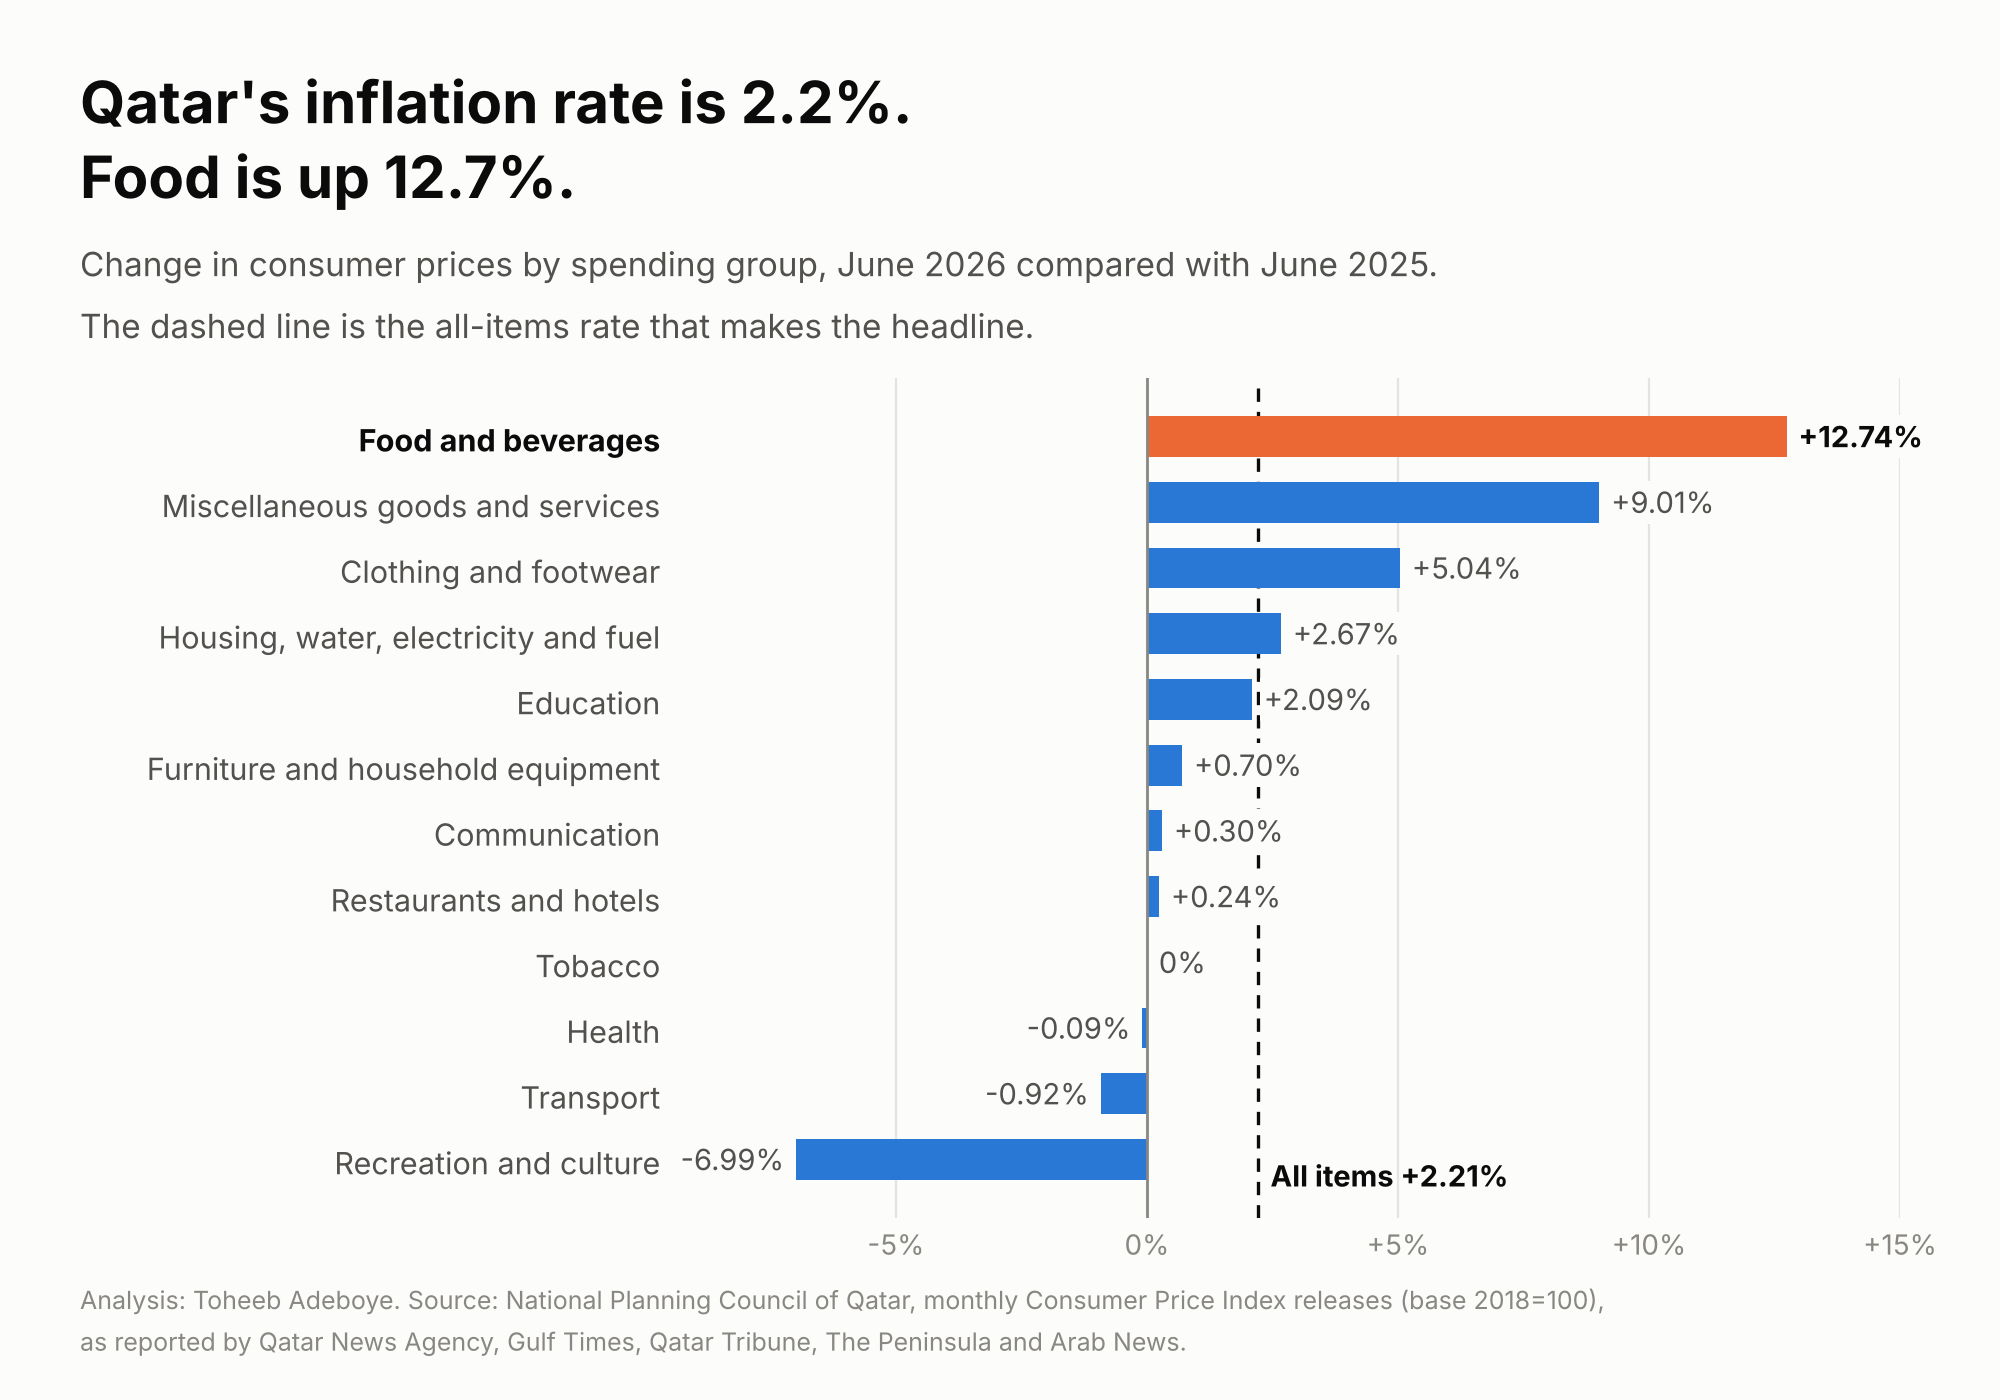

In [6]:
from IPython.display import Image
Image('../images/qatar-food-inflation-chart.png', width=800)

## 5. Finding 2: when the gap opened

In [7]:
yoy = tidy[tidy.measure == 'yoy_pct'].pivot(index='month', columns='cpi_group', values='value')[['food_beverages', 'all_items', 'recreation_culture', 'transport']]
print('all-items range:', yoy.all_items.min(), 'to', yoy.all_items.max())
assert yoy.loc['2026-02', 'food_beverages'] == 2.05 and yoy.loc['2026-04', 'food_beverages'] == 10.41
yoy

all-items range: 1.95 to 2.62


cpi_group,food_beverages,all_items,recreation_culture,transport
month,,,,
2025-12,0.63,1.95,1.44,-0.42
2026-01,2.87,2.28,4.90,-0.48
2026-02,2.05,2.51,4.92,-1.70
2026-04,10.41,2.62,-3.18,-0.55
2026-05,11.71,2.20,-5.70,-3.00
2026-06,12.74,2.21,-6.99,-0.92


In [8]:
food_mom = tidy[(tidy.cpi_group == 'food_beverages') & (tidy.measure == 'mom_pct')][['month', 'value', 'publishers', 'verification']]
food_mom

,month,value,publishers,verification
12,2025-12,0.19,Qatar Tribune; The Peninsula,two-publishers
42,2026-01,-0.59,Qatar Tribune; The Peninsula,two-publishers
72,2026-02,0.16,Qatar Tribune; The Peninsula,two-publishers
97,2026-03,6.90,Arab News,single-publisher
118,2026-04,1.48,Arab News; Qatar News Agency; Qatar Tribune,two-publishers
145,2026-05,1.84,Qatar News Agency; Qatar Tribune,two-publishers
169,2026-06,0.98,Gulf Times; Qatar Tribune,two-publishers


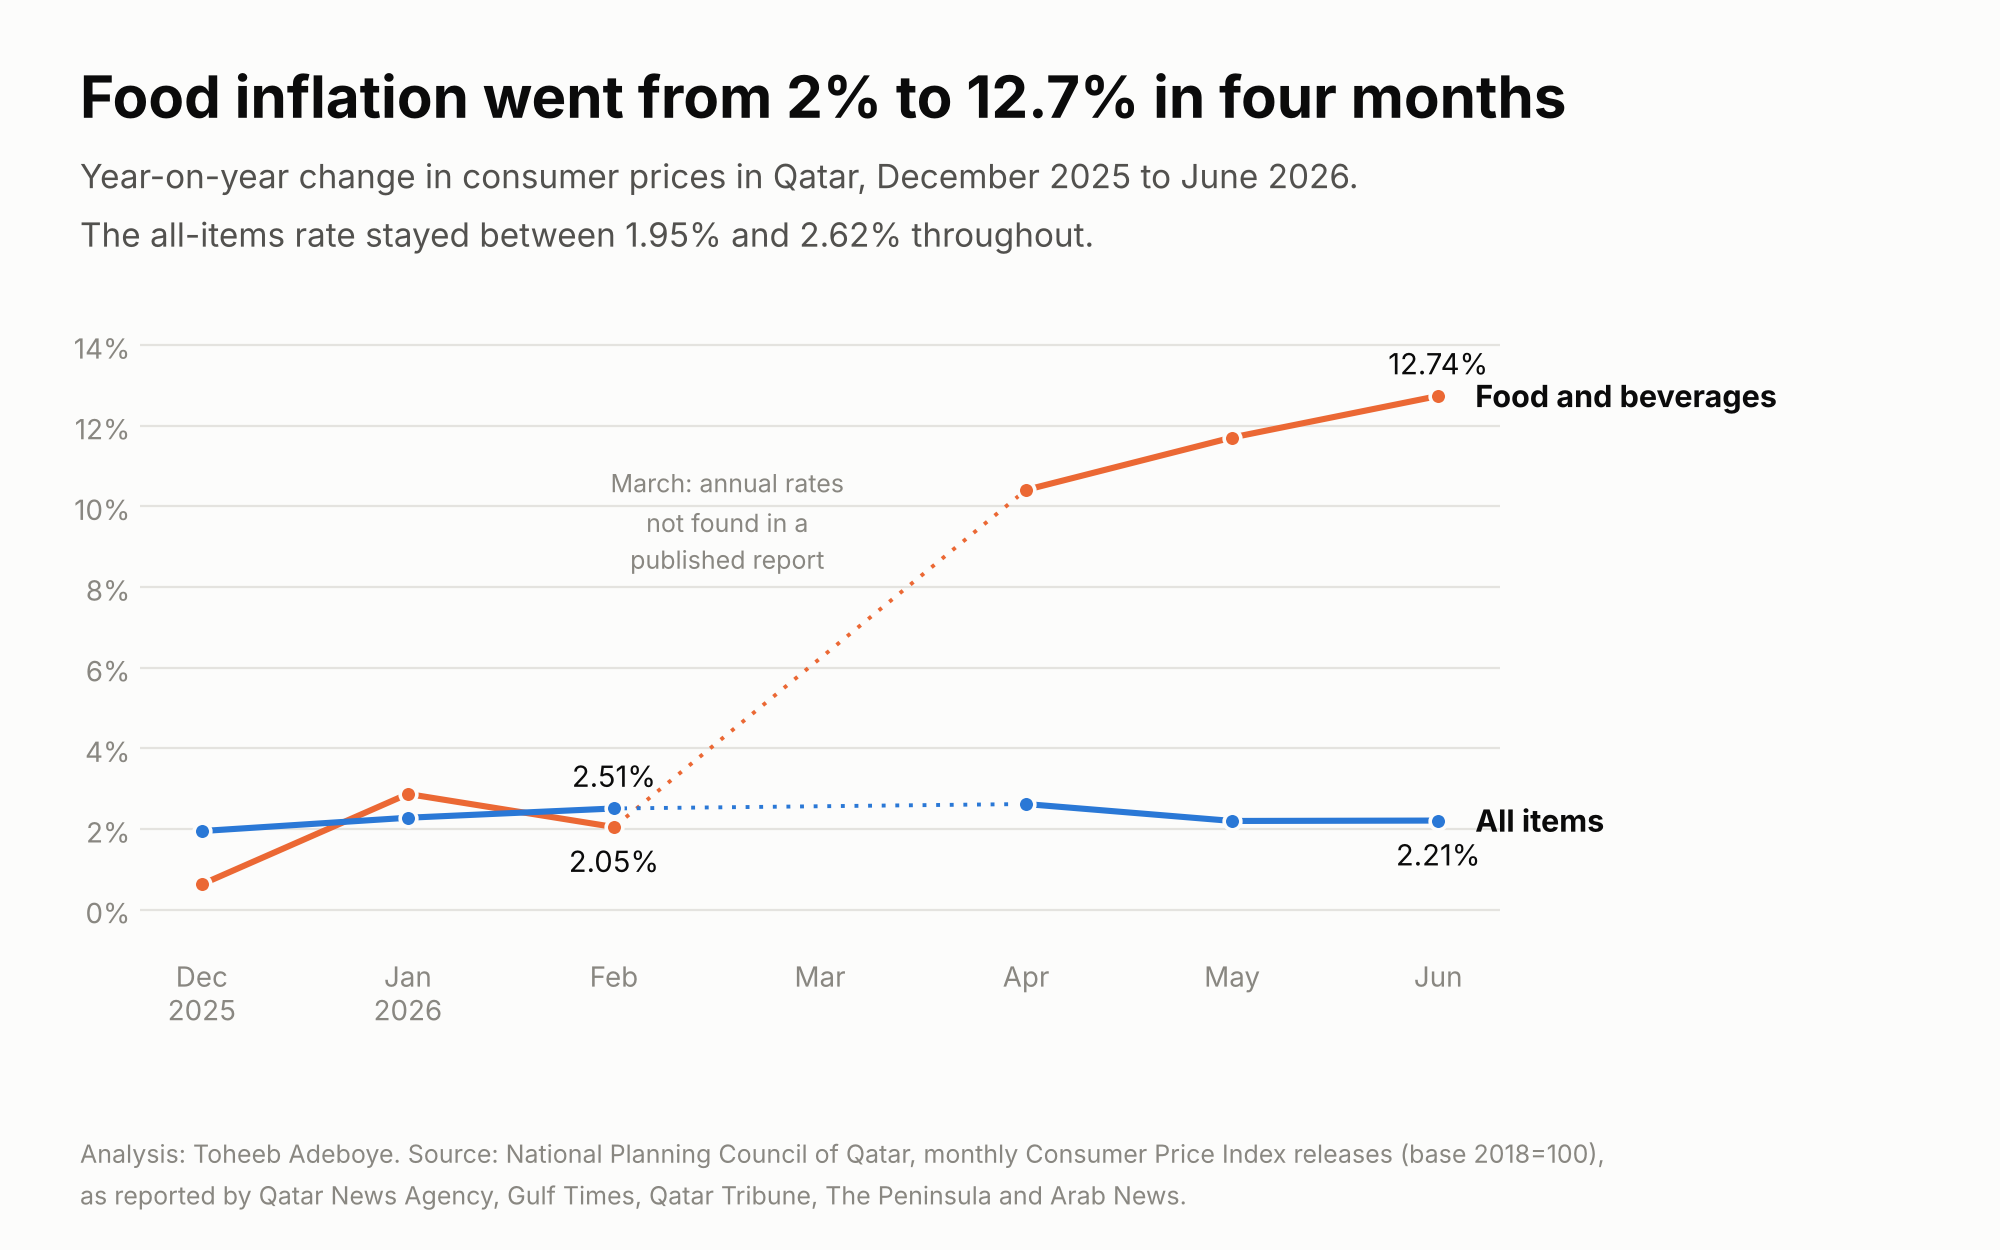

In [9]:
Image('../images/food_vs_all_items_yoy.png', width=800)

Food rose 6.9% in March alone. That monthly figure rests on one publisher (Arab News). A consistency test: the annual rate went from 2.05% in February to 10.41% in April, and both of those are confirmed in two publishers. That jump is only possible if food rose by about 8% more over March and April 2026 than it did over March and April 2025. The chained 2026 monthly changes for those two months give 8.5%, which is consistent.

In [10]:
two_month_2026 = (1 + val('2026-03', 'food_beverages', 'mom_pct') / 100) * (1 + val('2026-04', 'food_beverages', 'mom_pct') / 100)
yoy_ratio = (1 + 10.41 / 100) / (1 + 2.05 / 100)
implied_2025 = (two_month_2026 / yoy_ratio - 1) * 100
print(f'Food, March and April 2026 chained: {(two_month_2026 - 1) * 100:.2f}%')
print(f'Rise needed to move the annual rate from 2.05% to 10.41%: {(yoy_ratio - 1) * 100:.2f}% more than a year earlier')
print(f'Implied change over March and April 2025: {implied_2025:.2f}%')
assert -1 < implied_2025 < 1.5

Food, March and April 2026 chained: 8.48%
Rise needed to move the annual rate from 2.05% to 10.41%: 8.19% more than a year earlier
Implied change over March and April 2025: 0.27%


## 6. Finding 3: what offset food between February and June

Chain the monthly changes for each group from March to June, with February as the base.

In [11]:
mom = tidy[tidy.measure == 'mom_pct'].pivot(index='month', columns='cpi_group', values='value')
months = ['2026-03', '2026-04', '2026-05', '2026-06']
mine = (((1 + mom.loc[months] / 100).prod() - 1) * 100).round(2)
built = cum[(cum.window == 'since_feb_2026') & (cum.method == 'chained monthly changes')].set_index('cpi_group').cumulative_change_pct
assert (mine - built.reindex(mine.index)).abs().max() < 0.005, 'notebook and build script disagree'
idx_change = round((val('2026-06', 'all_items', 'index') / val('2026-02', 'all_items', 'index') - 1) * 100, 2)
print(f"Food: {mine['food_beverages']}% | Recreation and culture: {mine['recreation_culture']}% | All items, from index levels: {idx_change}%")
assert mine['food_beverages'] == 11.56 and mine['recreation_culture'] == -10.94 and idx_change == -0.43
mine.sort_values(ascending=False).to_frame('change_feb_to_jun_pct')

Food: 11.56% | Recreation and culture: -10.94% | All items, from index levels: -0.43%


,change_feb_to_jun_pct
cpi_group,
food_beverages,11.56
housing_utilities,0.67
clothing_footwear,0.66
furniture_household,0.05
education,0.01
tobacco,0.00
health,-0.10
communication,-0.43
all_items,-0.44


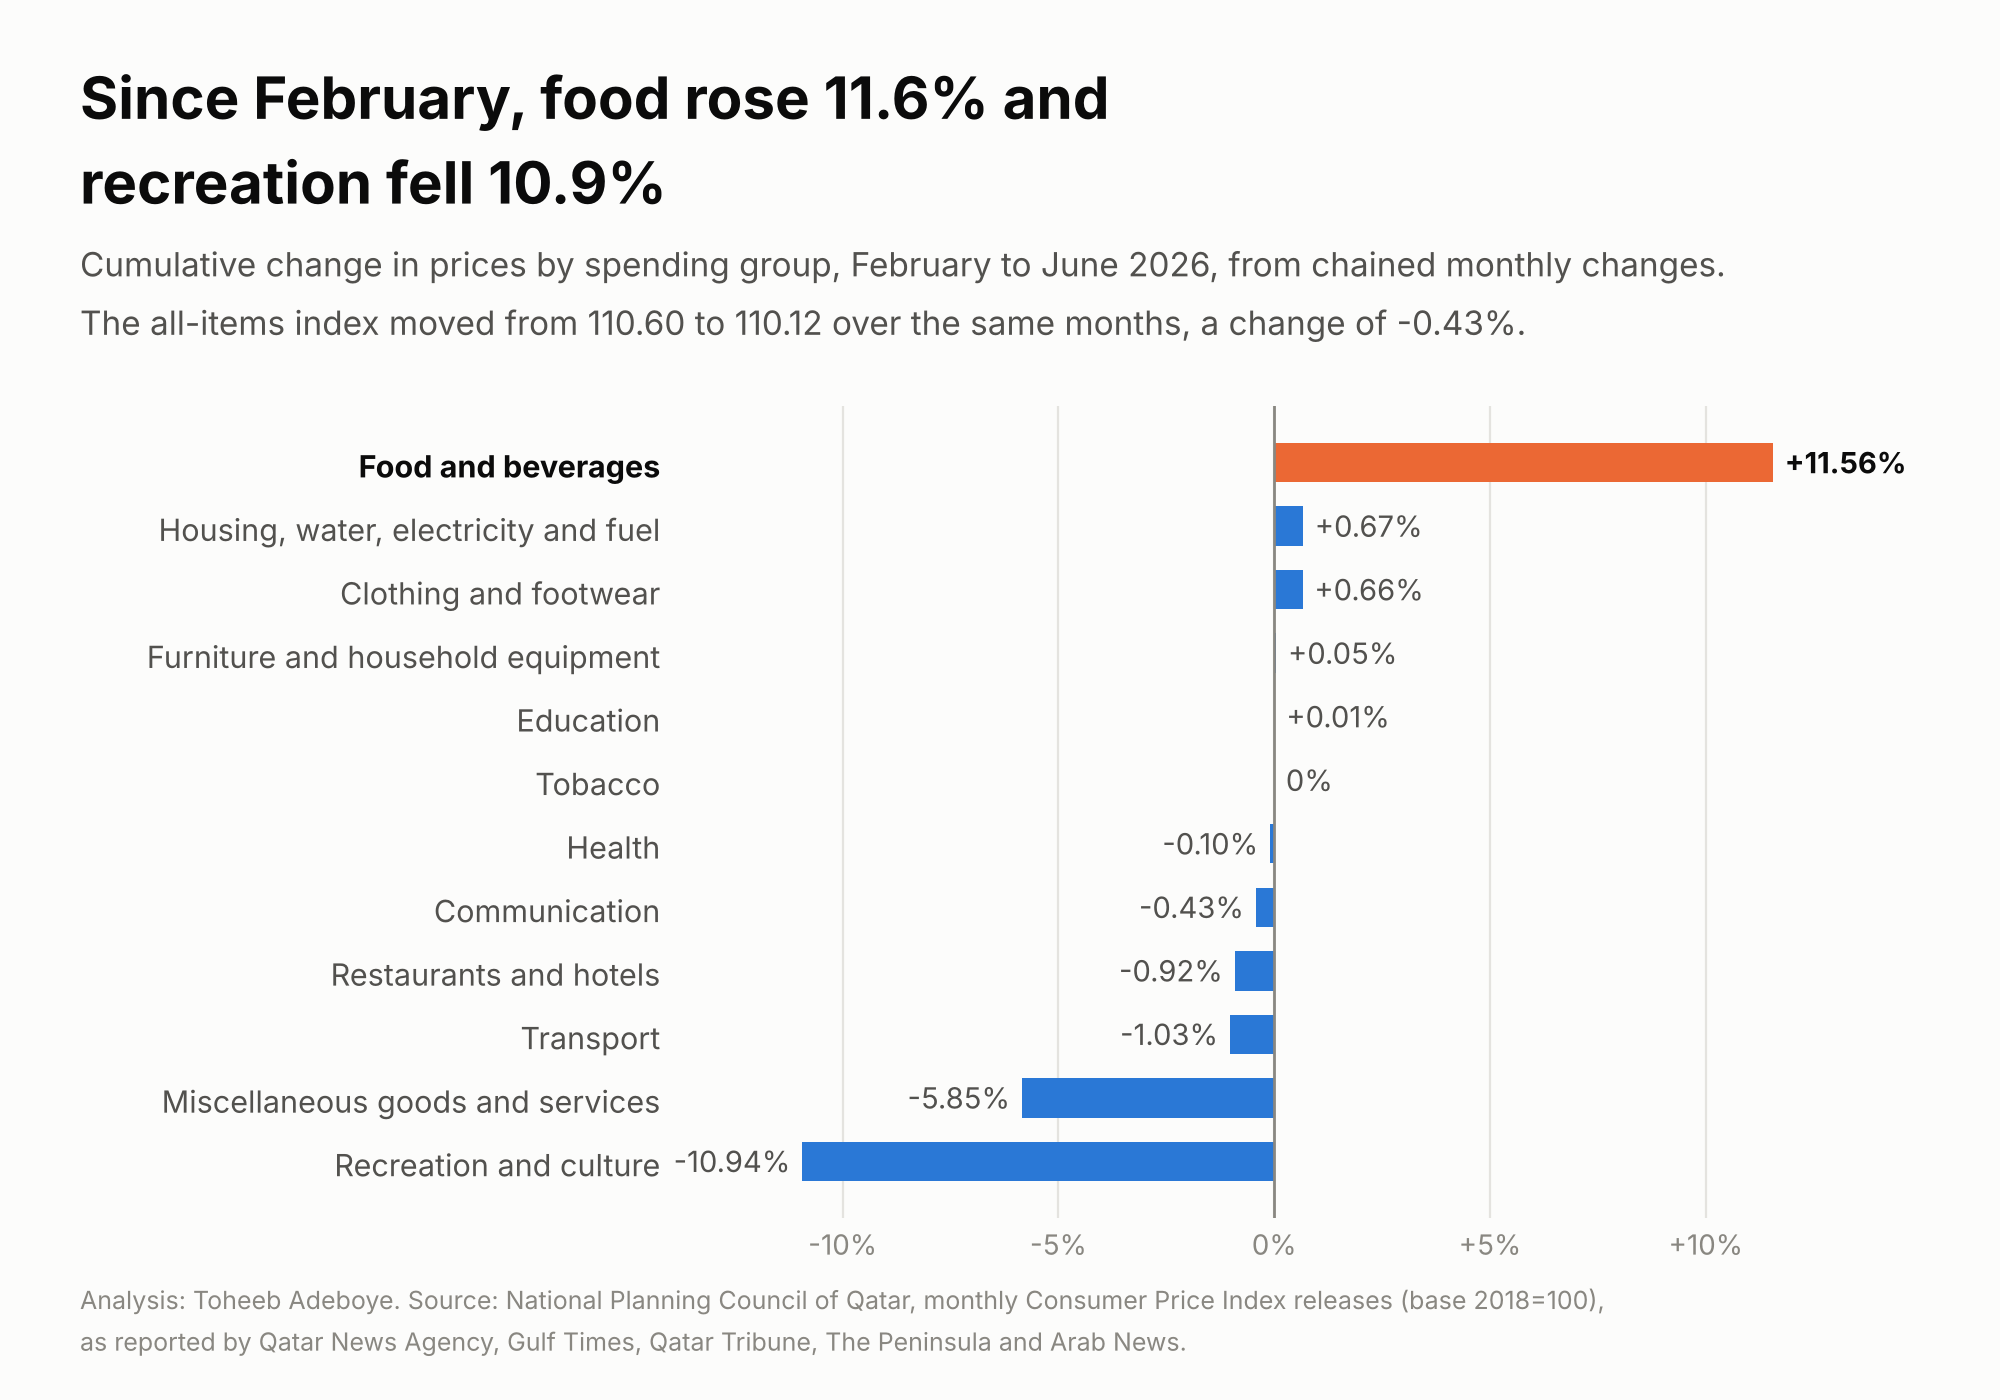

In [12]:
Image('../images/cumulative_change_since_february.png', width=800)

## 7. Sensitivity: a different starting month

Starting from December 2025 instead of February 2026 barely moves food (11.08% against 11.56%) but doubles the fall in recreation and culture, because December carries a seasonal 6.84% rise in that group. The food result does not depend on the choice of window. The recreation result does, so the year-on-year figure (-6.99%) is the safer one to quote for that group.

In [13]:
alt = cum[cum.method == 'chained monthly changes'].pivot(index='group_label', columns='window', values='cumulative_change_pct')[['since_feb_2026', 'since_dec_2025']]
alt.sort_values('since_feb_2026', ascending=False)

window,since_feb_2026,since_dec_2025
group_label,,
Food and beverages,11.56,11.08
"Housing, water, electricity and fuel",0.67,0.82
Clothing and footwear,0.66,1.88
Furniture and household equipment,0.05,0.25
Education,0.01,0.07
Tobacco,0.00,0.00
Health,-0.10,0.17
Communication,-0.43,-0.19
All items,-0.44,-2.02


## 8. Rounding

Monthly changes are published to two decimals (the March food figure to one). Chaining four rounded changes can move the food result by at most about 0.08 points, so 11.56% is reported in the text as 11.6%.

In [14]:
half = {'2026-03': 0.05, '2026-04': 0.005, '2026-05': 0.005, '2026-06': 0.005}
lo = hi = 1.0
for m in months:
    v = val(m, 'food_beverages', 'mom_pct')
    lo *= 1 + (v - half[m]) / 100
    hi *= 1 + (v + half[m]) / 100
print(f'Food, February to June 2026: between {(lo - 1) * 100:.2f}% and {(hi - 1) * 100:.2f}%')

Food, February to June 2026: between 11.49% and 11.63%


## 9. Summary

- Food and beverages: +12.74% year on year in June 2026. All items: +2.21%.
- The food rate was 2.05% in February and 10.41% in April. March alone added 6.9% month on month (one publisher).
- From February to June food rose 11.6% while the all-items index fell 0.43%, because recreation and culture, miscellaneous goods and services, transport and restaurants fell.
- Annual group rates for March are missing, and five May annual rates rest on one publisher at one decimal.